In [2]:
import csv
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.interpolate import interp1d

ELECTRON_DIR = "data_iron"
source_file = "source.txt"

# 1. Criar uma grade comum de Energia (ex: de 1e-3 a 1e5 GeV com 200 pontos)
E_comum = np.logspace(-3, 5, 200)

dados_populacao = {
    'nomes': [],
    't_acc_matrix': [],
    't_cool_matrix': [],
    'E_max': [],
    't_acc_1GeV': [],
    'frac_sync_Emax': []
}

print("Lendo os arquivos e processando os dados...")

with open(source_file, mode='r') as csvfile:
    reader = csv.DictReader(csvfile)
    
    for row in reader:
        nome = row['name']
        filename = f"{ELECTRON_DIR}/{nome}_electrons.csv"
        
        if not os.path.exists(filename):
            continue
            
        # Listas temporárias para ler o arquivo
        E_tmp, acc_tmp, cool_tmp, sync_tmp = [], [], [], []
        
        with open(filename, 'r') as f:
            csv_reader = csv.DictReader(f)
            for d in csv_reader:
                E_tmp.append(float(d['E_GeV']))
                acc_tmp.append(float(d['rate_acc']))
                
                # Soma das perdas totais
                total_cool = float(d['rate_sync']) + float(d['rate_bremss']) + float(d['rate_ic_0']) + float(d['rate_ic_1'])
                cool_tmp.append(total_cool)
                sync_tmp.append(float(d['rate_sync']))
                
        # Interpolação para a grade comum
        f_acc = interp1d(E_tmp, acc_tmp, fill_value="extrapolate")
        f_cool = interp1d(E_tmp, cool_tmp, fill_value="extrapolate")
        f_sync = interp1d(E_tmp, sync_tmp, fill_value="extrapolate")
        
        acc_interp = f_acc(E_comum)
        cool_interp = f_cool(E_comum)
        sync_interp = f_sync(E_comum)
        
        # Encontrar E_max (onde o resfriamento supera a aceleração)
        # Pegamos o primeiro índice onde cool > acc
        idx_max = np.where(cool_interp > acc_interp)[0]
        if len(idx_max) > 0:
            e_m = E_comum[idx_max[0]]
            frac_sync = sync_interp[idx_max[0]] / cool_interp[idx_max[0]]
        else:
            e_m = E_comum[-1] # Se não cruzar, assume o limite superior
            frac_sync = sync_interp[-1] / cool_interp[-1]
            
        # Taxa em 1 GeV (aproximadamente no índice onde E_comum é 1.0)
        idx_1gev = np.argmin(np.abs(E_comum - 1.0))
        t_acc_1g = acc_interp[idx_1gev]
        
        # Salvar na população
        dados_populacao['nomes'].append(nome)
        dados_populacao['t_acc_matrix'].append(acc_interp)
        dados_populacao['t_cool_matrix'].append(cool_interp)
        dados_populacao['E_max'].append(e_m)
        dados_populacao['t_acc_1GeV'].append(t_acc_1g)
        dados_populacao['frac_sync_Emax'].append(frac_sync)

# 2. AGORA SIM, converter matrizes para Numpy Arrays
t_acc_matrix = np.array(dados_populacao['t_acc_matrix'])
t_cool_matrix = np.array(dados_populacao['t_cool_matrix'])
E_max_array = np.array(dados_populacao['E_max'])
t_acc_1GeV_array = np.array(dados_populacao['t_acc_1GeV'])
nomes_array = np.array(dados_populacao['nomes'])


# 3. IDENTIFICAR AS FONTES DE DESTAQUE (Agora funciona, pois os arrays já existem)
# Ordena os índices das fontes com base no t_acc em 1 GeV (do menor para o maior)
indices_ordenados = np.argsort(t_acc_1GeV_array)

# Pegando os índices das 3 fontes mais baixas (lower) e 3 mais altas (upper)
qtd_destaque = 3
indices_lower = indices_ordenados[:qtd_destaque]
indices_upper = indices_ordenados[-qtd_destaque:]

# Juntando tudo em uma única lista de índices
indices_destaque = np.concatenate((indices_lower, indices_upper))

# Criando a lista de nomes dinamicamente
fontes_destaque = [nomes_array[i] for i in indices_destaque]

print(f"\nFontes Lower identificadas: {[nomes_array[i] for i in indices_lower]}")
print(f"Fontes Upper identificadas: {[nomes_array[i] for i in indices_upper]}\n")

Lendo os arquivos e processando os dados...

Fontes Lower identificadas: [np.str_('SDSS J135226.71+140528.5'), np.str_('SDSS J075354.98+130916.5'), np.str_('SDSS J114232.84+262919.9')]
Fontes Upper identificadas: [np.str_('SDSS J140528.32+304602.0'), np.str_('SDSS J150636.57+092618.3'), np.str_('SDSS J090734.91+325722.9')]



<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Samuel Bernardo\AppData\Local\Temp\ipykernel_16404\3203859788.py:20: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label('$\log_{10}$ E$_{max}$ [GeV]', fontsize=14)


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

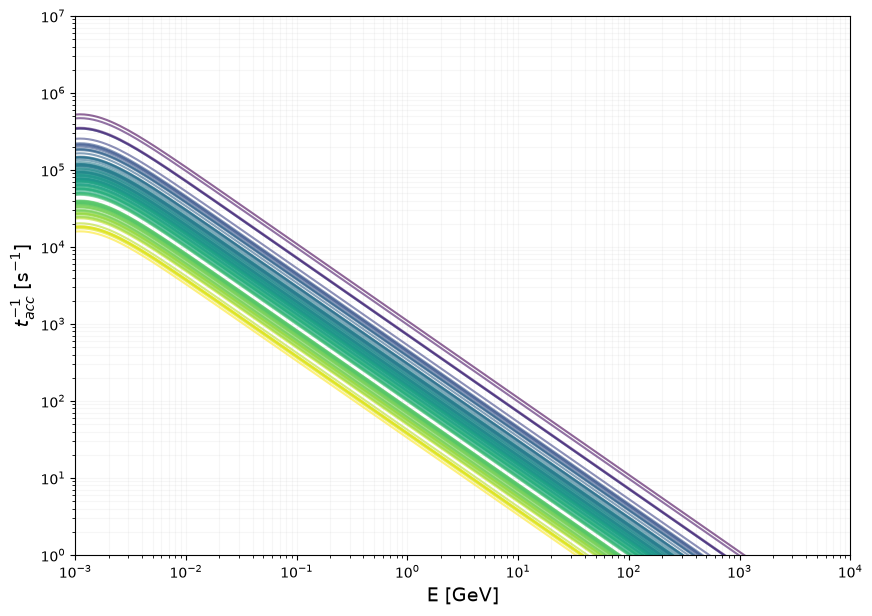

In [3]:
plt.figure(figsize=(10, 7))
cmap = plt.get_cmap('viridis')
# Normaliza as cores pelo log do E_max
norm = plt.Normalize(vmin=np.log10(np.min(E_max_array)), vmax=np.log10(np.max(E_max_array)))

for i in range(len(nomes_array)):
    cor = cmap(norm(np.log10(E_max_array[i])))
    plt.loglog(E_comum, t_acc_matrix[i], color=cor, alpha=0.6, linewidth=1.5)

plt.xlabel('E [GeV]', fontsize=14)
plt.ylabel('$t_{acc}^{-1}$ [s$^{-1}$]', fontsize=14)
plt.xlim(1e-3, 1e4)
plt.ylim(1e0, 1e7)
plt.grid(True, which="both", ls="-", alpha=0.1)

# Adicionando a barra de cores
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('$\log_{10}$ E$_{max}$ [GeV]', fontsize=14)
plt.title('A. Mesmo espaguete, cor codificando $E_{max}$')
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Samuel Bernardo\AppData\Local\Temp\ipykernel_16404\465470628.py:14: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label('$\log_{10}$ $t_{acc}^{-1}$ [s$^{-1}$]')
C:\Users\Samuel Bernardo\AppData\Local\Temp\ipykernel_16404\465470628.py:34: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label('$\log_{10} (t_{acc}^{-1} / t_{perdas}^{-1})$')


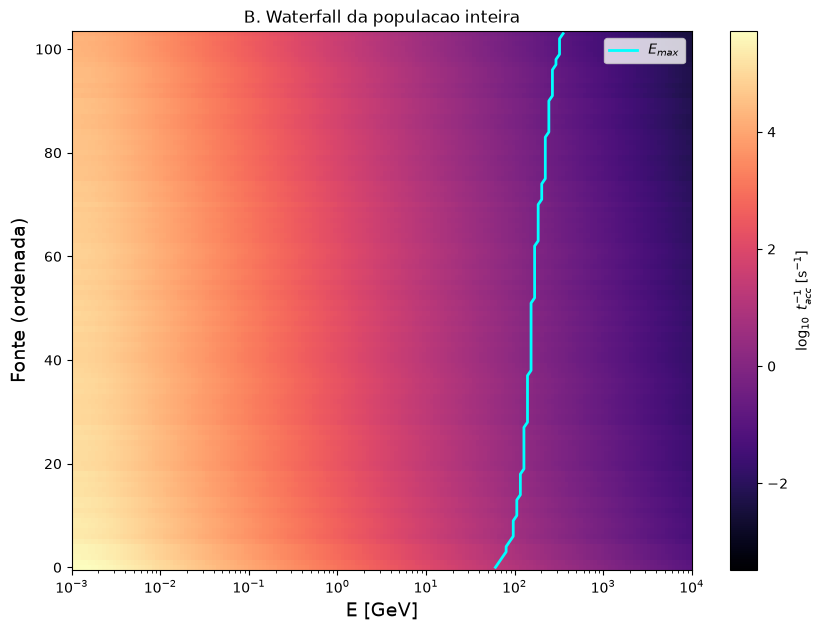

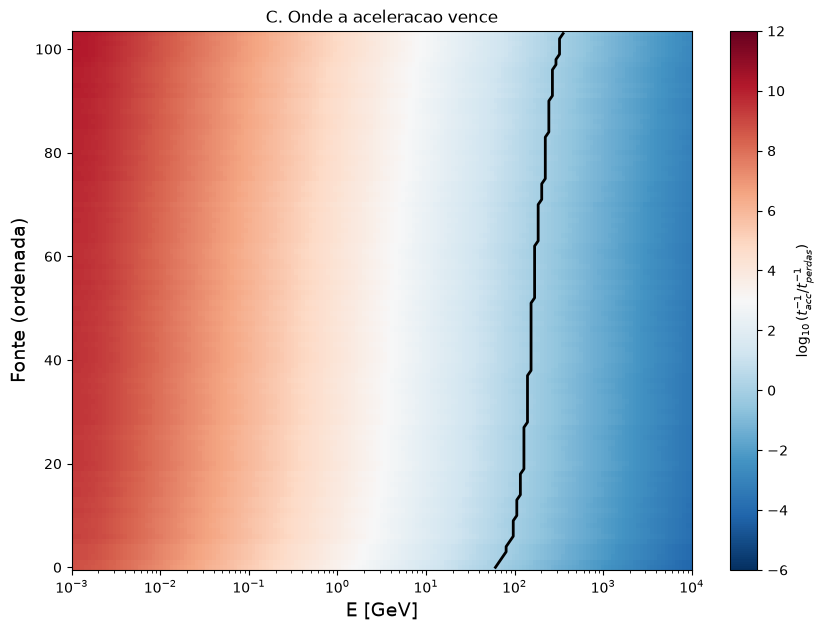

In [4]:
# Ordenar as fontes pelo E_max (cria aquele visual de escadinha)
ordem = np.argsort(E_max_array)
matriz_ordenada_acc = t_acc_matrix[ordem]
matriz_ordenada_cool = t_cool_matrix[ordem]
E_max_ordenado = E_max_array[ordem]

# --- Para o Waterfall (Gráfico B) ---
plt.figure(figsize=(10, 7))
X, Y = np.meshgrid(E_comum, np.arange(len(nomes_array)))
Z_acc = np.log10(matriz_ordenada_acc)

plt.pcolormesh(X, Y, Z_acc, cmap='magma', shading='auto')
cbar = plt.colorbar()
cbar.set_label('$\log_{10}$ $t_{acc}^{-1}$ [s$^{-1}$]')

# Plotando a linha do E_max por cima
plt.plot(E_max_ordenado, np.arange(len(E_max_ordenado)), color='cyan', lw=2, label='$E_{max}$')

plt.xscale('log')
plt.xlim(1e-3, 1e4)
plt.xlabel('E [GeV]', fontsize=14)
plt.ylabel('Fonte (ordenada)', fontsize=14)
plt.title('B. Waterfall da populacao inteira')
plt.legend(loc='upper right')
plt.show()

# --- Para o Mapa Divergente (Gráfico C) ---
plt.figure(figsize=(10, 7))
# Razão entre aceleração e perda: valores > 0 acc vence, < 0 perda vence
Z_razao = np.log10(matriz_ordenada_acc / matriz_ordenada_cool)

plt.pcolormesh(X, Y, Z_razao, cmap='RdBu_r', shading='auto', vmin=-6, vmax=12)
cbar = plt.colorbar()
cbar.set_label('$\log_{10} (t_{acc}^{-1} / t_{perdas}^{-1})$')

plt.plot(E_max_ordenado, np.arange(len(E_max_ordenado)), color='black', lw=2, label='$E_{max}$')

plt.xscale('log')
plt.xlim(1e-3, 1e4)
plt.xlabel('E [GeV]', fontsize=14)
plt.ylabel('Fonte (ordenada)', fontsize=14)
plt.title('C. Onde a aceleracao vence')
plt.show()

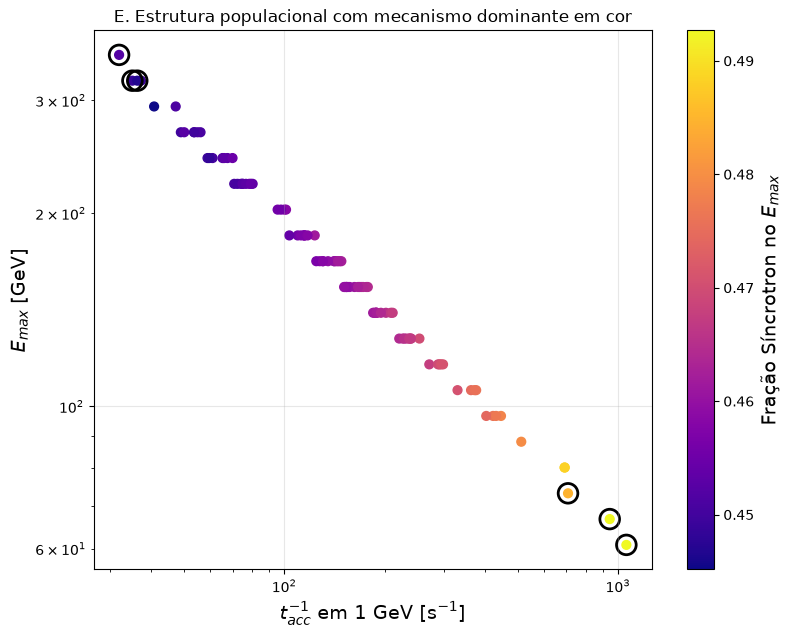

In [5]:
plt.figure(figsize=(9, 7))
frac = dados_populacao['frac_sync_Emax']

scatter = plt.scatter(t_acc_1GeV_array, E_max_array, c=frac, cmap='plasma', s=40)
cbar = plt.colorbar(scatter)
cbar.set_label('Fração Síncrotron no $E_{max}$', fontsize=14)

# Destacar fontes específicas
for i, nome in enumerate(nomes_array):
    if nome in fontes_destaque:
        plt.scatter(t_acc_1GeV_array[i], E_max_array[i], 
                    facecolors='none', edgecolors='black', s=200, lw=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_{acc}^{-1}$ em 1 GeV [s$^{-1}$]', fontsize=14)
plt.ylabel('$E_{max}$ [GeV]', fontsize=14)
plt.title('E. Estrutura populacional com mecanismo dominante em cor')
plt.grid(True, alpha=0.3)
plt.show()

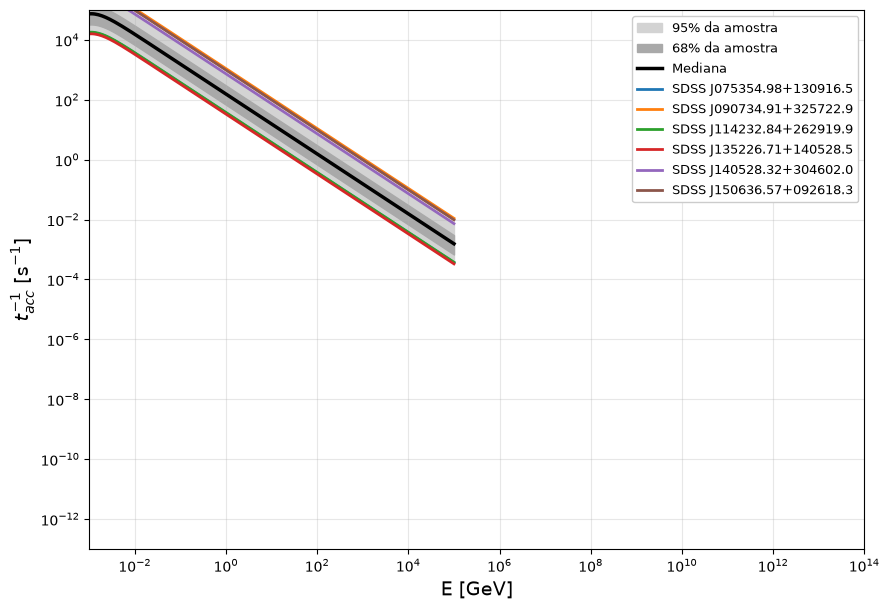

In [6]:
plt.figure(figsize=(10, 7))

# Calcular percentis da amostra inteira (ao longo do eixo 0, que são as fontes)
p50 = np.percentile(t_acc_matrix, 50, axis=0) # Mediana
p16 = np.percentile(t_acc_matrix, 16, axis=0) # ~ 68% inferior
p84 = np.percentile(t_acc_matrix, 84, axis=0) # ~ 68% superior
p02 = np.percentile(t_acc_matrix, 2.5, axis=0) # ~ 95% inferior
p97 = np.percentile(t_acc_matrix, 97.5, axis=0) # ~ 95% superior

# Preencher bandas
plt.fill_between(E_comum, p02, p97, color='lightgray', label='95% da amostra')
plt.fill_between(E_comum, p16, p84, color='darkgray', label='68% da amostra')
plt.loglog(E_comum, p50, color='black', lw=2.5, label='Mediana')

# Plotar as fontes em destaque individualmente
cores = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']
idx_cor = 0
for i, nome in enumerate(nomes_array):
    if nome in fontes_destaque:
        plt.loglog(E_comum, t_acc_matrix[i], color=cores[idx_cor % len(cores)], lw=2, label=nome)
        idx_cor += 1

plt.xlabel('E [GeV]', fontsize=14)
plt.ylabel('$t_{acc}^{-1}$ [s$^{-1}$]', fontsize=14)
plt.xlim(1e-3, 1e14)
plt.ylim(1e-13, 1e5)
plt.legend(fontsize=9, loc='upper right', framealpha=1)
plt.grid(True, alpha=0.3)
plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Samuel Bernardo\AppData\Local\Temp\ipykernel_16404\3970340532.py:13: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log_{10}$ $t_{acc}^{-1}$ em E = 1 GeV [s$^{-1}$]', fontsize=14)


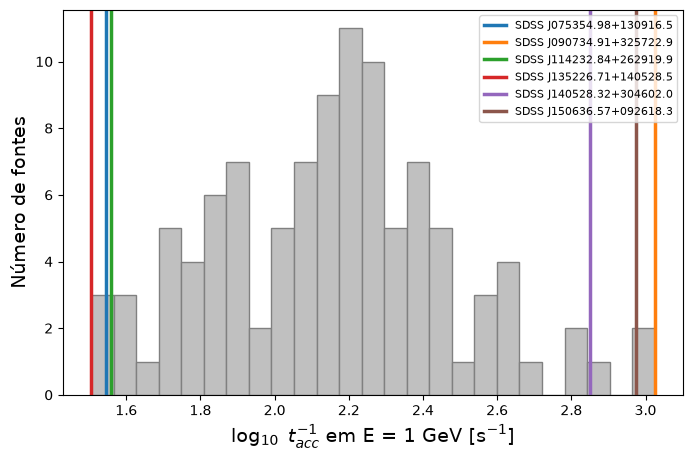

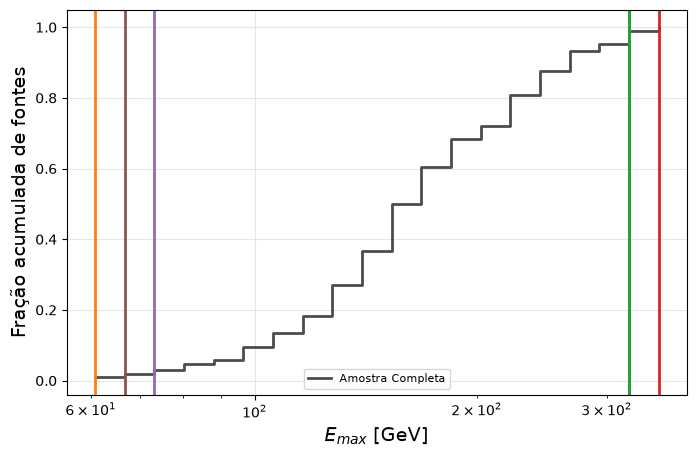

In [7]:
# --- Fig 3: Histograma (Distribuição de t_acc em 1 GeV) ---
plt.figure(figsize=(8, 5))
log_t_acc = np.log10(t_acc_1GeV_array)

plt.hist(log_t_acc, bins=25, color='silver', edgecolor='gray')

idx_cor = 0
for i, nome in enumerate(nomes_array):
    if nome in fontes_destaque:
        plt.axvline(log_t_acc[i], color=cores[idx_cor % len(cores)], lw=2.5, label=nome)
        idx_cor += 1

plt.xlabel('$\log_{10}$ $t_{acc}^{-1}$ em E = 1 GeV [s$^{-1}$]', fontsize=14)
plt.ylabel('Número de fontes', fontsize=14)
plt.legend(fontsize=8)
plt.show()

# --- Fig 6: ECDF (Distribuição Acumulada de E_max) ---
plt.figure(figsize=(8, 5))
x = np.sort(E_max_array)
y = np.arange(1, len(x) + 1) / len(x) # Calcula a fração acumulada

plt.step(x, y, where='post', color='black', lw=2, alpha=0.7, label='Amostra Completa')

idx_cor = 0
for i, nome in enumerate(nomes_array):
    if nome in fontes_destaque:
        plt.axvline(E_max_array[i], color=cores[idx_cor % len(cores)], lw=2)
        idx_cor += 1

plt.xscale('log')
plt.xlabel('$E_{max}$ [GeV]', fontsize=14)
plt.ylabel('Fração acumulada de fontes', fontsize=14)
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
import pandas as pd

# Lendo a tabela de parâmetros físicos
df_params = pd.read_csv("all_calculated_parameters.csv")

# Listas para guardar os parâmetros na exata mesma ordem das fontes do gráfico
B_prime_array = []
L_j_array = []
M_array = []

for nome in nomes_array:
    # Ajusta o nome caso seus arquivos usem "_" (ex: SDSS_J010852) 
    # e a tabela use espaço (SDSS J010852). Pega os primeiros 12 caracteres.
    nome_busca = nome.replace("_", " ")[:12] 
    
    # Procura a fonte na tabela
    linha = df_params[df_params['Source_Name'].str.contains(nome_busca, na=False, regex=False)]
    
    if not linha.empty:
        B_prime_array.append(linha['B_prime_Gauss'].values[0])
        L_j_array.append(linha['L_j'].values[0])
        M_array.append(linha['M'].values[0])
    else:
        # Se não achar por algum motivo, coloca NaN para não quebrar o código
        B_prime_array.append(np.nan)
        L_j_array.append(np.nan)
        M_array.append(np.nan)

# Converte para Arrays Numpy
B_prime_array = np.array(B_prime_array)
L_j_array = np.array(L_j_array)
M_array = np.array(M_array)

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Samuel Bernardo\AppData\Local\Temp\ipykernel_16404\3592766059.py:8: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label('$\log_{10}$ $t_{acc}^{-1}$ em 1 GeV [s$^{-1}$]', fontsize=14)


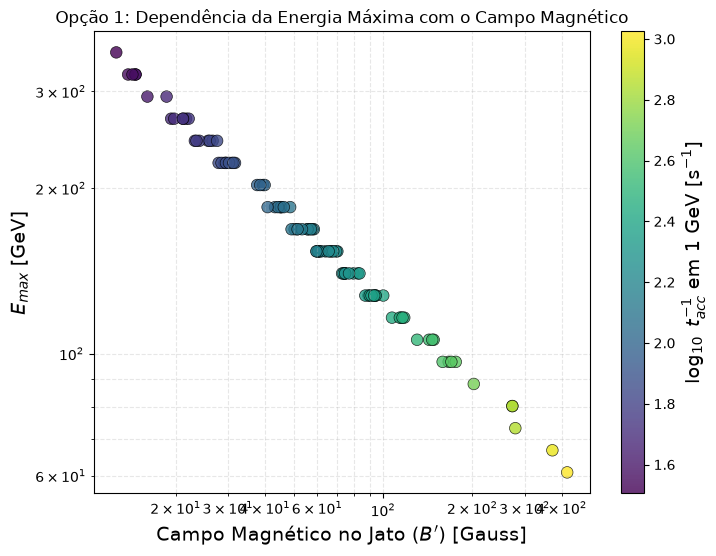

In [10]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(B_prime_array, E_max_array, 
                      c=np.log10(t_acc_1GeV_array), cmap='viridis', 
                      s=70, alpha=0.8, edgecolors='black', linewidth=0.5)

cbar = plt.colorbar(scatter)
cbar.set_label('$\log_{10}$ $t_{acc}^{-1}$ em 1 GeV [s$^{-1}$]', fontsize=14)

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Campo Magnético no Jato ($B'$) [Gauss]", fontsize=14)
plt.ylabel("$E_{max}$ [GeV]", fontsize=14)
plt.title("Opção 1: Dependência da Energia Máxima com o Campo Magnético")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Samuel Bernardo\AppData\Local\Temp\ipykernel_16404\2392251501.py:22: SyntaxWarning: invalid escape sequence '\o'
  ax3.set_xlabel("Massa do Buraco Negro ($M$) [M$_\odot$]", fontsize=12)


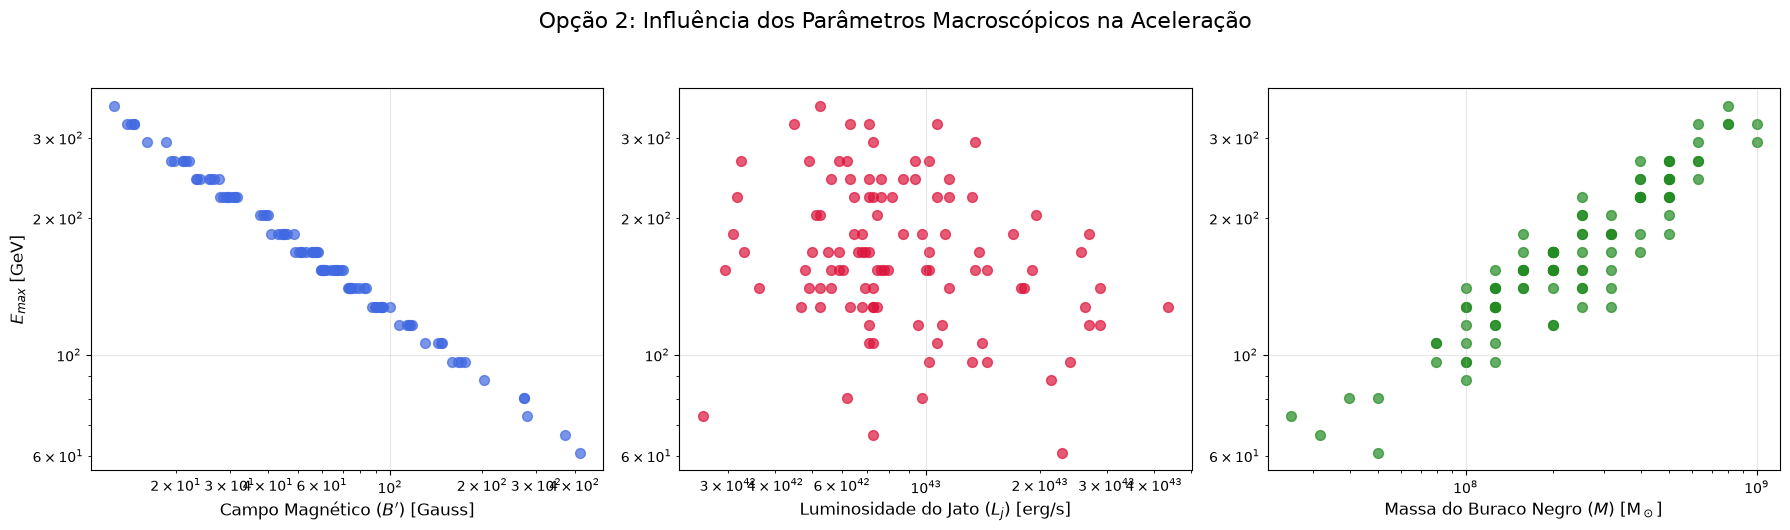

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Painel 1: B' vs E_max
ax1.scatter(B_prime_array, E_max_array, color='royalblue', s=50, alpha=0.7)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel("Campo Magnético ($B'$) [Gauss]", fontsize=12)
ax1.set_ylabel("$E_{max}$ [GeV]", fontsize=12)
ax1.grid(True, alpha=0.3)

# Painel 2: Luminosidade vs E_max
ax2.scatter(L_j_array, E_max_array, color='crimson', s=50, alpha=0.7)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel("Luminosidade do Jato ($L_j$) [erg/s]", fontsize=12)
ax2.grid(True, alpha=0.3)

# Painel 3: Massa vs E_max
ax3.scatter(M_array, E_max_array, color='forestgreen', s=50, alpha=0.7)
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel("Massa do Buraco Negro ($M$) [M$_\odot$]", fontsize=12)
ax3.grid(True, alpha=0.3)

plt.suptitle("Opção 2: Influência dos Parâmetros Macroscópicos na Aceleração", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Samuel Bernardo\AppData\Local\Temp\ipykernel_16404\1972963953.py:30: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label("$\log_{10}$ $B'$ [Gauss]", fontsize=14)


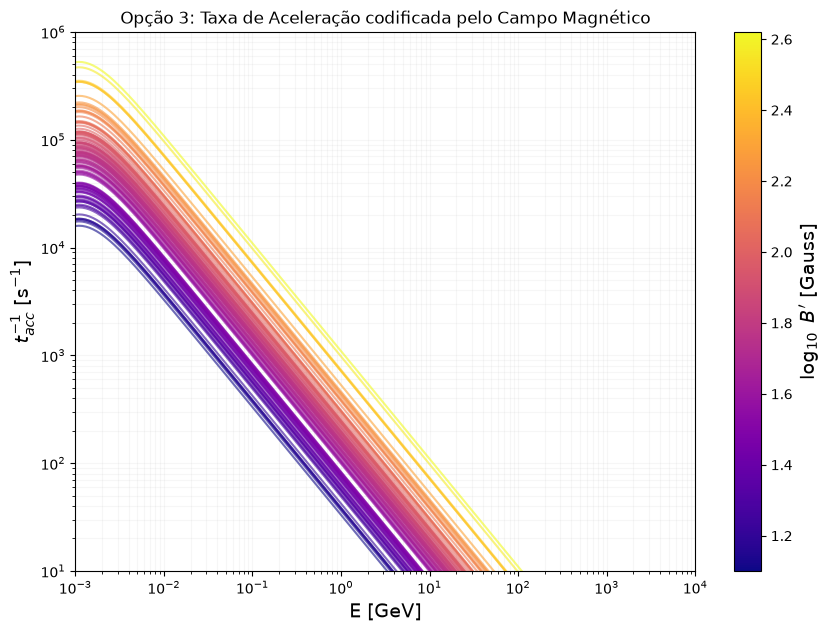

In [13]:
plt.figure(figsize=(10, 7))
cmap = plt.get_cmap('plasma')

# Máscara para ignorar fontes que não foram encontradas no CSV (NaNs)
mask = ~np.isnan(B_prime_array)

if mask.any():
    # Normaliza as cores pelo log do campo magnético
    norm = plt.Normalize(vmin=np.log10(np.min(B_prime_array[mask])), 
                         vmax=np.log10(np.max(B_prime_array[mask])))

    for i in range(len(nomes_array)):
        if not np.isnan(B_prime_array[i]):
            cor = cmap(norm(np.log10(B_prime_array[i])))
            plt.loglog(E_comum, t_acc_matrix[i], color=cor, alpha=0.6, linewidth=1.5)

    plt.xlabel('E [GeV]', fontsize=14)
    plt.ylabel('$t_{acc}^{-1}$ [s$^{-1}$]', fontsize=14)
    
    # Ajuste os limites abaixo conforme sua grade real
    plt.xlim(1e-3, 1e4)
    plt.ylim(1e1, 1e6) 
    plt.grid(True, which="both", ls="-", alpha=0.1)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    
    # A CORREÇÃO ESTÁ AQUI: ax=plt.gca() avisa ao matplotlib onde ancorar a barra
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label("$\log_{10}$ $B'$ [Gauss]", fontsize=14)
    
    plt.title("Opção 3: Taxa de Aceleração codificada pelo Campo Magnético")
    
plt.show()

<>:92: SyntaxWarning: invalid escape sequence '\l'
<>:92: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Samuel Bernardo\AppData\Local\Temp\ipykernel_16404\1672950139.py:92: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label("$\log_{10}$ $B'$ [Gauss]", fontsize=14)


Lendo e interpolando todas as taxas...


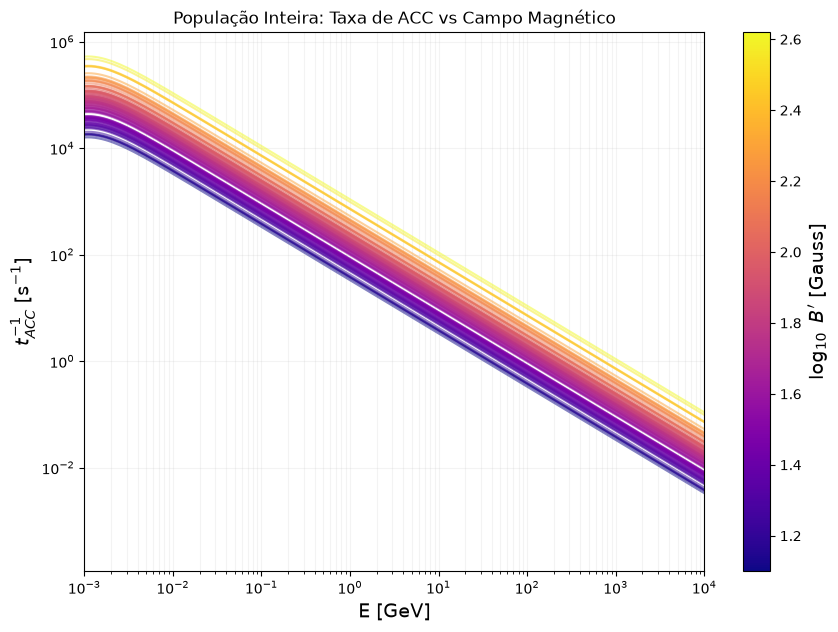

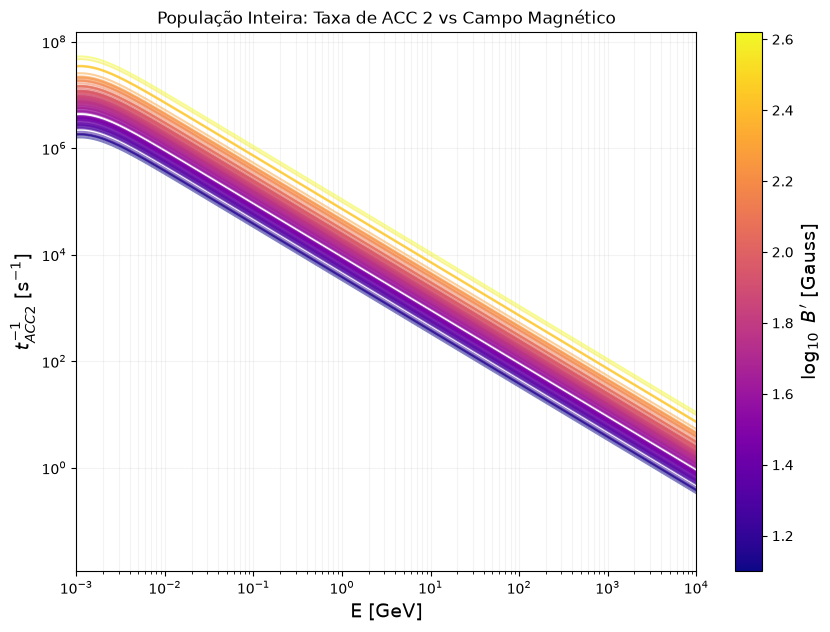

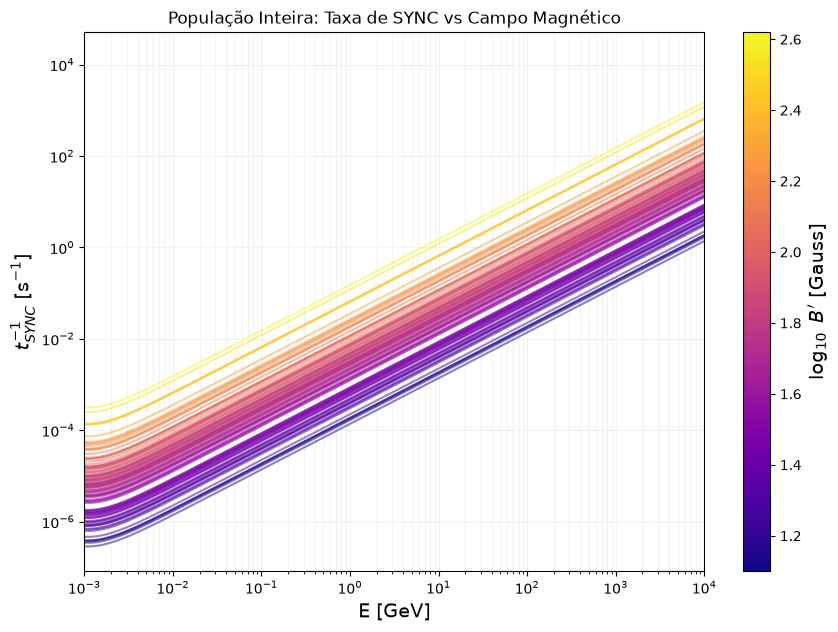

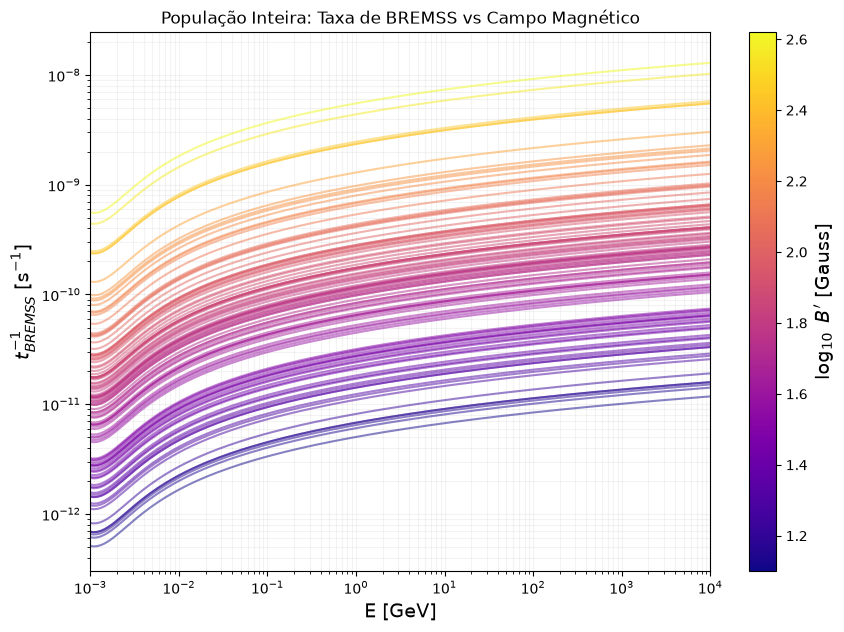

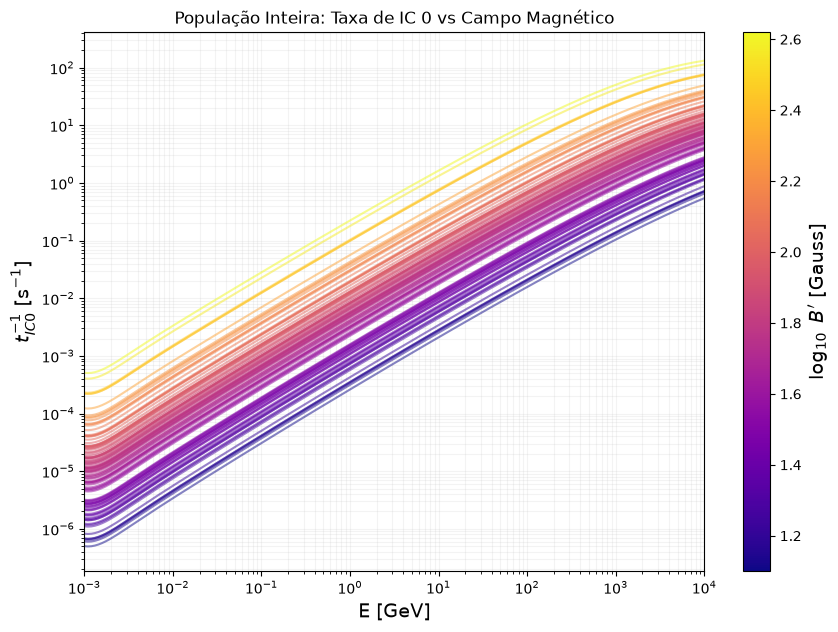

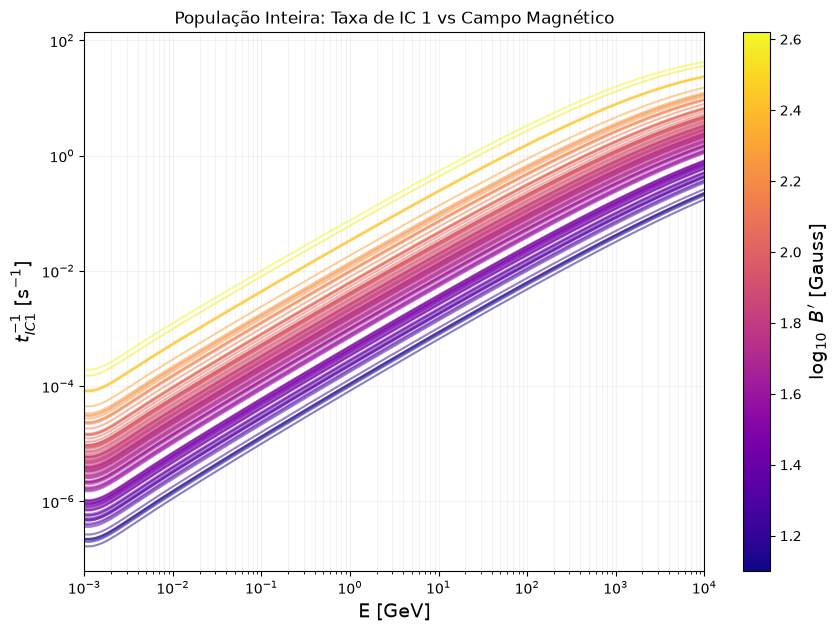

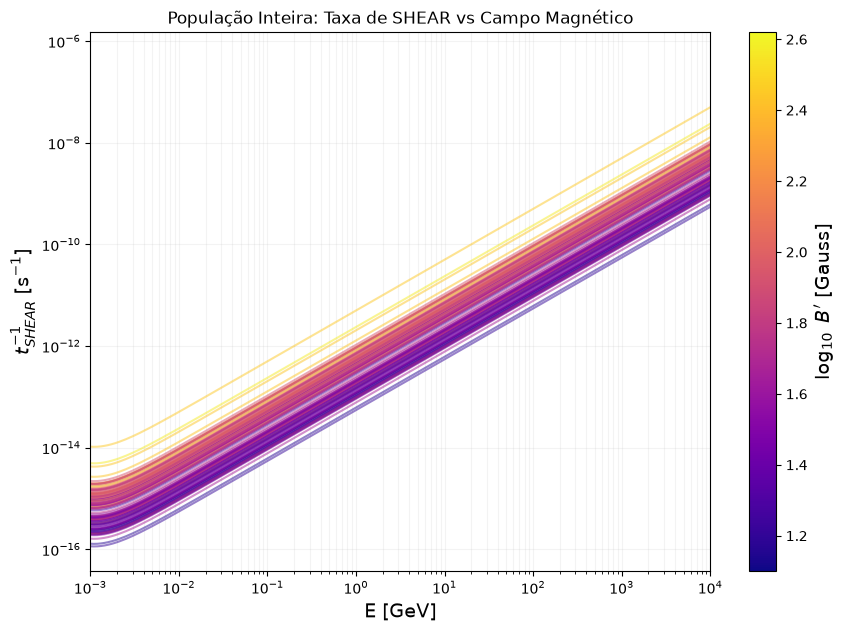

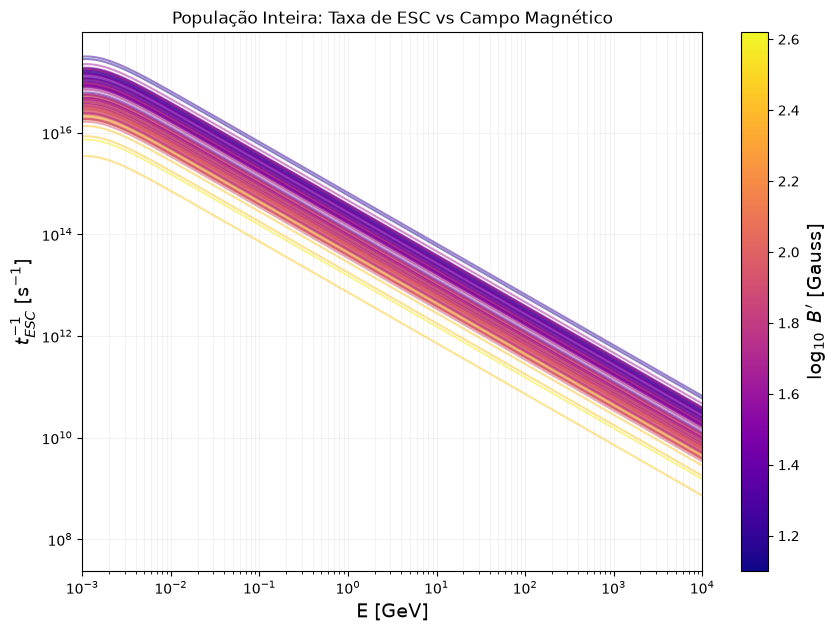

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import csv
import os
from scipy.interpolate import interp1d

# 1. Defina todas as colunas que você quer gerar os gráficos
colunas_de_taxas = [
    'rate_acc', 'rate_acc_2', 'rate_sync', 'rate_bremss', 
    'rate_ic_0', 'rate_ic_1', 'Shear', 'ESC'
]

# Vamos criar um dicionário para guardar a matriz de cada taxa
matrizes_das_taxas = {coluna: [] for coluna in colunas_de_taxas}
nomes_validos = []
B_prime_valido = []

print("Lendo e interpolando todas as taxas...")

# 2. Lendo os arquivos para extrair todas as curvas de uma vez
for i, nome in enumerate(nomes_array):
    filename = f"{ELECTRON_DIR}/{nome}_electrons.csv"
    
    if not os.path.exists(filename):
        continue
        
    E_tmp = []
    dados_tmp = {coluna: [] for coluna in colunas_de_taxas}
    
    try:
        with open(filename, 'r') as f:
            csv_reader = csv.DictReader(f)
            for row in csv_reader:
                E_tmp.append(float(row['E_GeV']))
                for coluna in colunas_de_taxas:
                    # Usamos .get() com valor 1e-30 caso a coluna falte em alguma fonte
                    valor = float(row.get(coluna, 1e-30)) 
                    # Evitar zero absoluto para o loglog não dar erro
                    if valor <= 0: valor = 1e-30 
                    dados_tmp[coluna].append(valor)
                    
        # Interpola cada taxa para a grade E_comum e salva
        for coluna in colunas_de_taxas:
            f_interp = interp1d(E_tmp, dados_tmp[coluna], fill_value="extrapolate")
            matrizes_das_taxas[coluna].append(f_interp(E_comum))
            
        nomes_validos.append(nome)
        B_prime_valido.append(B_prime_array[i]) # Sincroniza com o B'
        
    except Exception as e:
        print(f"Erro ao processar {filename}: {e}")

# Converte para numpy array
B_prime_valido = np.array(B_prime_valido)
mask = ~np.isnan(B_prime_valido)

# 3. Gerando os gráficos um a um!
if mask.any():
    # A normalização de cores é a mesma para todos os gráficos
    norm = plt.Normalize(vmin=np.log10(np.min(B_prime_valido[mask])), 
                         vmax=np.log10(np.max(B_prime_valido[mask])))
    cmap = plt.get_cmap('plasma')

    for coluna in colunas_de_taxas:
        plt.figure(figsize=(10, 7))
        matriz_atual = np.array(matrizes_das_taxas[coluna])
        
        # Plota cada linha
        for i in range(len(nomes_validos)):
            if not np.isnan(B_prime_valido[i]):
                cor = cmap(norm(np.log10(B_prime_valido[i])))
                plt.loglog(E_comum, matriz_atual[i], color=cor, alpha=0.5, linewidth=1.5)

        plt.xlabel('E [GeV]', fontsize=14)
        
        # Ajustando o nome no eixo Y para ficar elegante
        nome_eixo = coluna.replace('rate_', '').replace('_', ' ').upper()
        plt.ylabel(f'$t_{{{nome_eixo}}}^{{-1}}$ [s$^{{-1}}$]', fontsize=14)
        
        plt.xlim(1e-3, 1e4)
        
        # OBS: Removi o plt.ylim() fixo porque taxas de resfriamento (como Bremsstrahlung)
        # caem para valores muito baixos. O matplotlib vai ajustar a altura automaticamente 
        # para caber a taxa específica de cada gráfico!
        
        plt.grid(True, which="both", ls="-", alpha=0.15)

        # Barra de cores
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=plt.gca())
        cbar.set_label("$\log_{10}$ $B'$ [Gauss]", fontsize=14)
        
        plt.title(f"População Inteira: Taxa de {nome_eixo} vs Campo Magnético")
        
        # Salva o plot automaticamente em uma pasta
        os.makedirs("image/comparativos", exist_ok=True)
        plt.savefig(f"image/comparativos/Espaguete_Bprime_{coluna}.png", bbox_inches='tight', dpi=150)
        
        plt.show()

<>:94: SyntaxWarning: invalid escape sequence '\l'
<>:94: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Samuel Bernardo\AppData\Local\Temp\ipykernel_16404\400750138.py:94: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label("$\log_{10}$ $B'$ [Gauss]", fontsize=14)


Lendo e interpolando as taxas do Ferro...


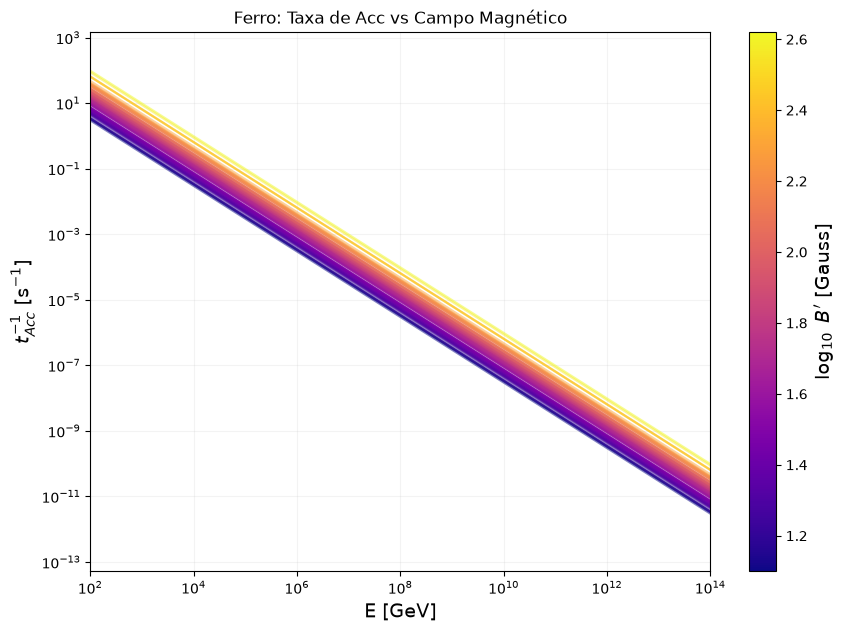

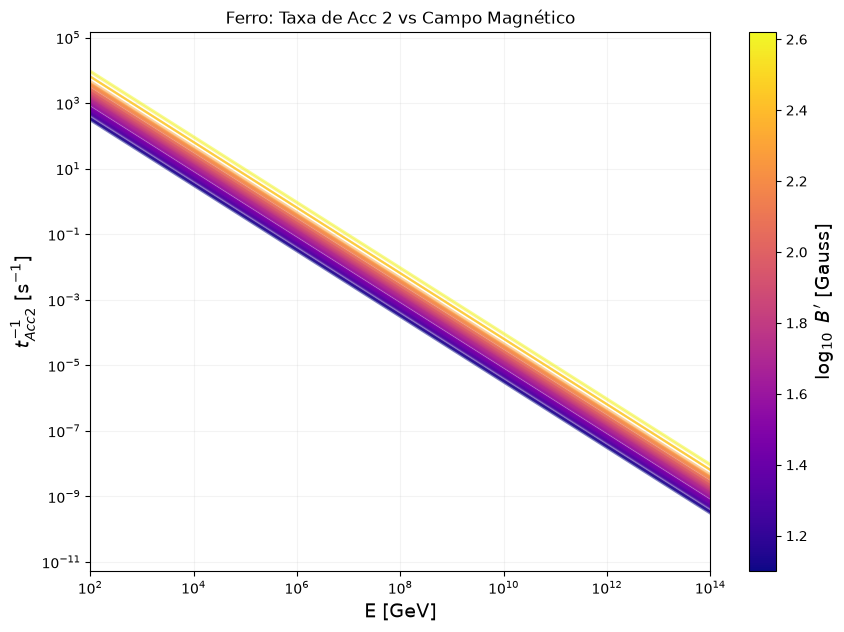

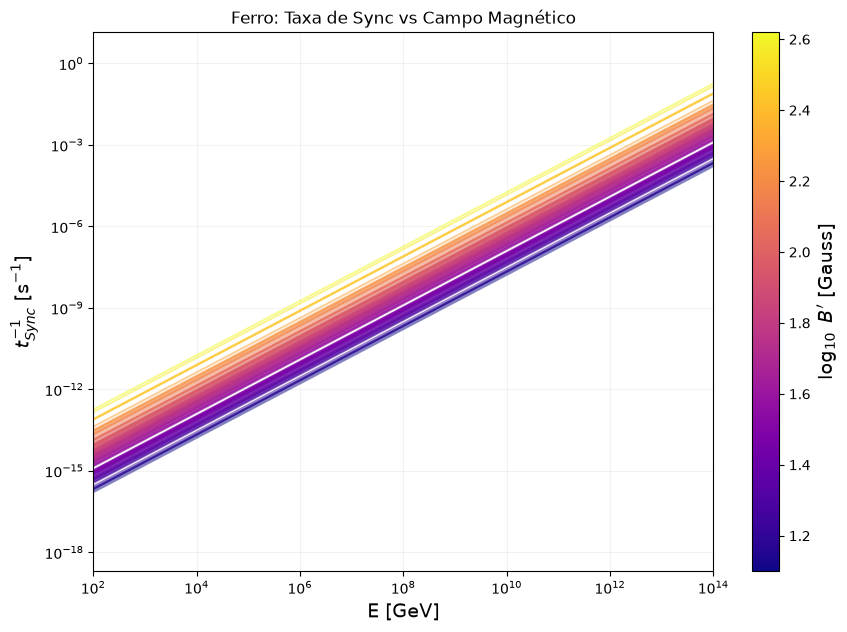

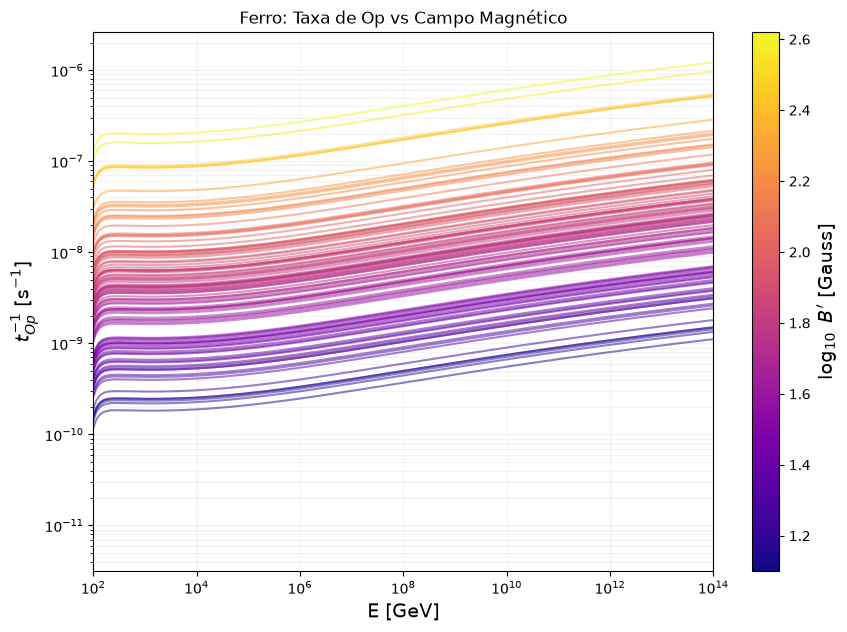

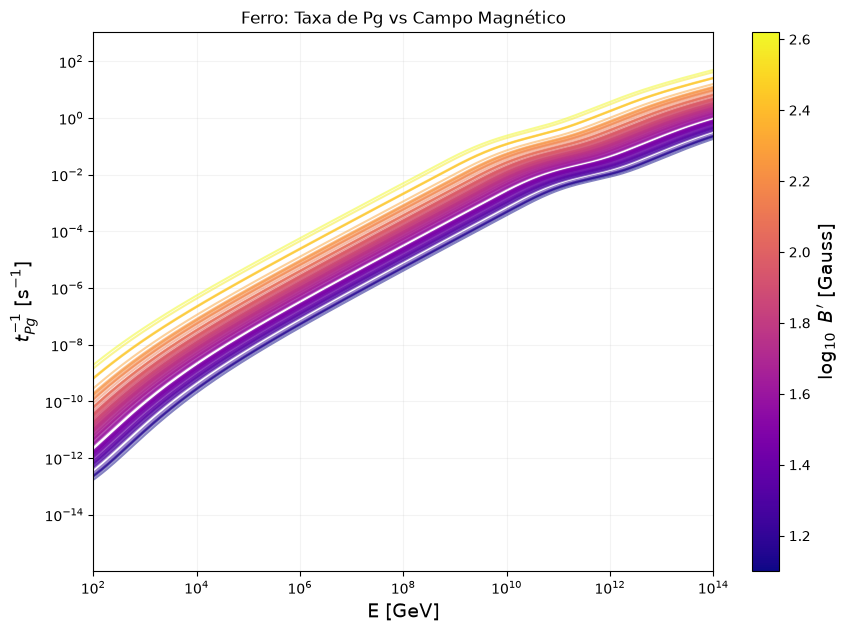

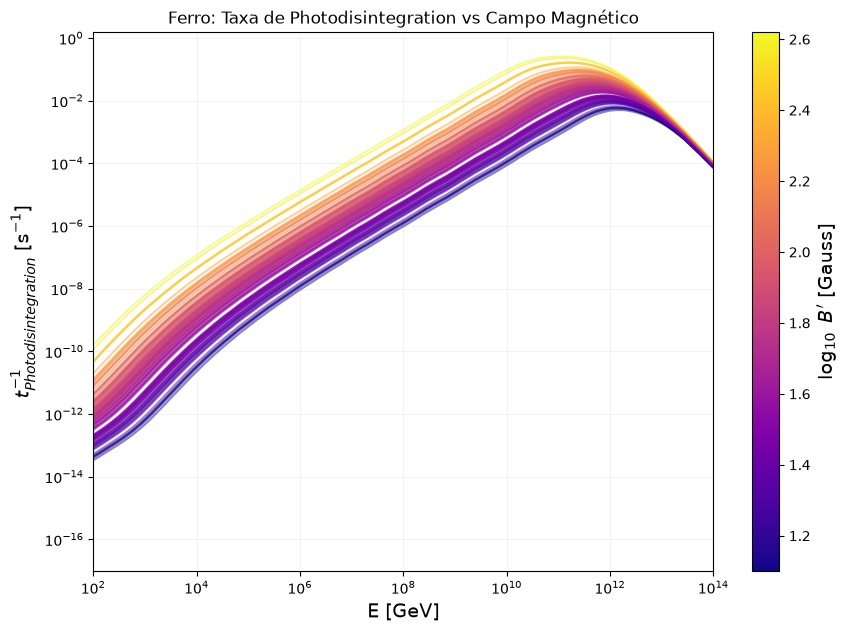

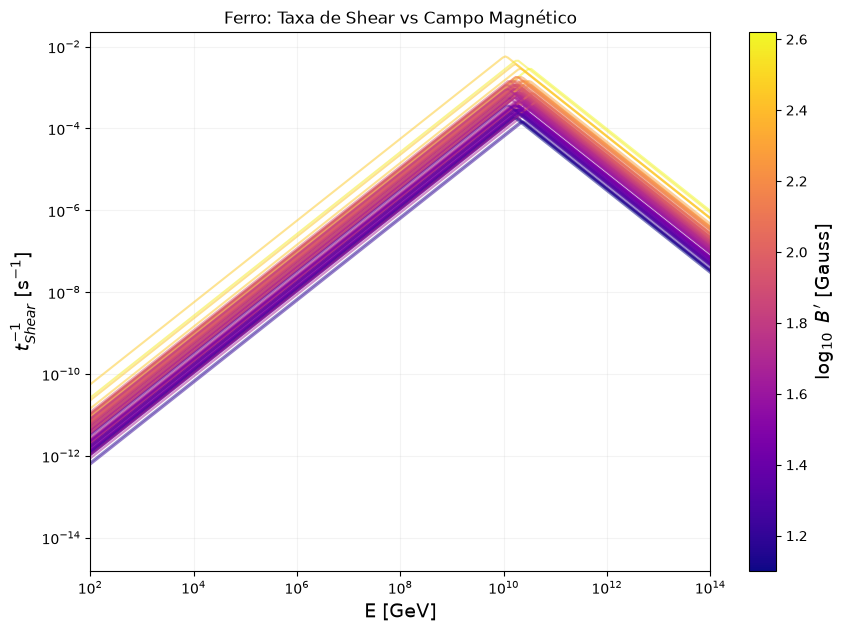

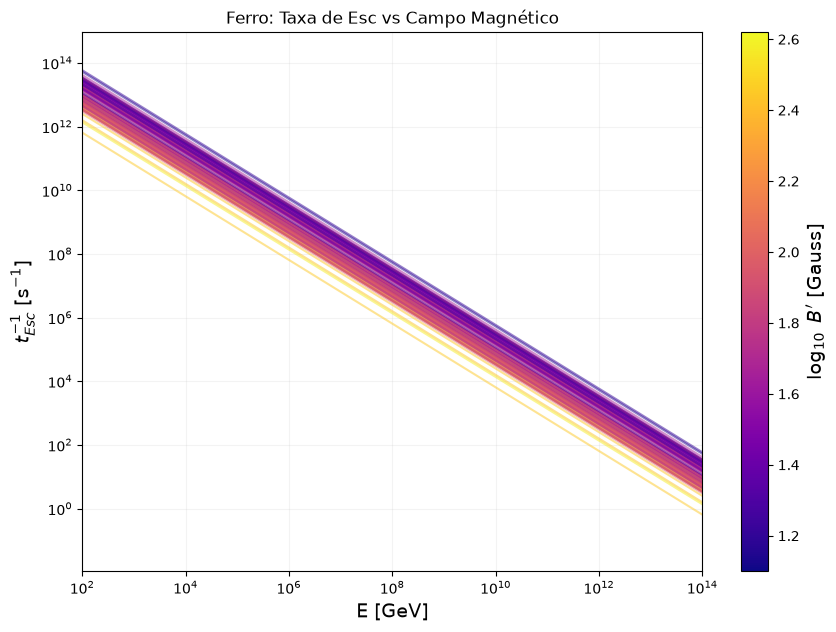

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import csv
import os
from scipy.interpolate import interp1d

IRON_DIR = "data_iron" # Ajuste se sua pasta tiver outro nome

# 1. Ajustando a grade comum para as energias altíssimas do Ferro (1 GeV a 1e15 GeV)
E_comum_iron = np.logspace(0, 15, 300)

# 2. Definindo as colunas exatas que existem no seu .csv do Ferro
colunas_iron = [
    'rate_acc', 'rate_acc_2', 'rate_sync', 
    'rate_Op', 'rate_pg', 'rate_photodisintegration', 
    'Shear', 'ESC'
]

matrizes_iron = {coluna: [] for coluna in colunas_iron}
nomes_iron_validos = []
B_prime_iron_valido = []

print("Lendo e interpolando as taxas do Ferro...")

# 3. Lendo os arquivos
for i, nome in enumerate(nomes_array):
    filename = f"{IRON_DIR}/{nome}_iron.csv"
    
    # Lida com a possibilidade do arquivo não ter o '_iron' dependendo de como foi salvo
    if not os.path.exists(filename):
        # Tenta sem o diretório caso os arquivos estejam na mesma pasta que o script
        filename = f"{nome}_iron.csv" 
        if not os.path.exists(filename):
            continue
        
    E_tmp = []
    dados_tmp = {coluna: [] for coluna in colunas_iron}
    
    try:
        with open(filename, 'r') as f:
            csv_reader = csv.DictReader(f)
            for row in csv_reader:
                # A COLUNA DE ENERGIA MUDOU DE NOME AQUI:
                E_tmp.append(float(row['E_prime_GeV_total']))
                for coluna in colunas_iron:
                    valor = float(row.get(coluna, 1e-35)) 
                    if valor <= 0: valor = 1e-35 
                    dados_tmp[coluna].append(valor)
                    
        # Interpola cada taxa para a nova grade E_comum_iron
        for coluna in colunas_iron:
            f_interp = interp1d(E_tmp, dados_tmp[coluna], fill_value="extrapolate")
            matrizes_iron[coluna].append(f_interp(E_comum_iron))
            
        nomes_iron_validos.append(nome)
        B_prime_iron_valido.append(B_prime_array[i])
        
    except Exception as e:
        print(f"Erro ao processar {filename}: {e}")

# Converte para array para facilitar
B_prime_iron_valido = np.array(B_prime_iron_valido)
mask = ~np.isnan(B_prime_iron_valido)

# 4. Gerando os gráficos um a um
if mask.any():
    norm = plt.Normalize(vmin=np.log10(np.min(B_prime_iron_valido[mask])), 
                         vmax=np.log10(np.max(B_prime_iron_valido[mask])))
    cmap = plt.get_cmap('plasma')

    for coluna in colunas_iron:
        plt.figure(figsize=(10, 7))
        matriz_atual = np.array(matrizes_iron[coluna])
        
        for i in range(len(nomes_iron_validos)):
            if not np.isnan(B_prime_iron_valido[i]):
                cor = cmap(norm(np.log10(B_prime_iron_valido[i])))
                plt.loglog(E_comum_iron, matriz_atual[i], color=cor, alpha=0.5, linewidth=1.5)

        plt.xlabel('E [GeV]', fontsize=14)
        
        # Deixa os nomes dos eixos bonitos (ex: Photodisintegration)
        nome_eixo = coluna.replace('rate_', '').replace('_', ' ').title()
        plt.ylabel(f'$t_{{{nome_eixo}}}^{{-1}}$ [s$^{{-1}}$]', fontsize=14)
        
        # Ajuste o limite X para a janela onde o Ferro "vive"
        plt.xlim(1e2, 1e14)
        
        plt.grid(True, which="both", ls="-", alpha=0.15)

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=plt.gca())
        cbar.set_label("$\log_{10}$ $B'$ [Gauss]", fontsize=14)
        
        plt.title(f"Ferro: Taxa de {nome_eixo} vs Campo Magnético")
        
        os.makedirs("image/comparativos_iron", exist_ok=True)
        plt.savefig(f"image/comparativos_iron/Espaguete_Iron_Bprime_{coluna}.png", bbox_inches='tight', dpi=150)
        
        plt.show()

In [ ]:
import csv
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

ELECTRON_DIR = "data_iron"
source_file = "source.txt"
params_file = "all_calculated_parameters.csv"

# Exact names of the sources identified previously
lower_sources = ['SDSS J135226.71+140528.5', 'SDSS J075354.98+130916.5', 'SDSS J114232.84+262919.9']
upper_sources = ['SDSS J140528.32+304602.0', 'SDSS J150636.57+092618.3', 'SDSS J090734.91+325722.9']

E_common = np.logspace(-3, 5, 200)

population_data = {
    'names': [],
    'E_max': [],
    'B': [],
    'mass': []
}

print("Loading the calculated parameters file...")
# 1. Read all_calculated_parameters.csv using Pandas
df_params = pd.read_csv(params_file)

# Create a dictionary where the key is the 'Source_Name' for ultra-fast indexing
params_dict = df_params.set_index('Source_Name').to_dict('index')

print("Reading rate files and extracting E_max...")

with open(source_file, mode='r') as csvfile:
    reader = csv.DictReader(csvfile)
    
    for row in reader:
        name = row['name']
        filename = f"{ELECTRON_DIR}/{name}_electrons.csv"
        
        if not os.path.exists(filename):
            continue
            
        # 2. Extract Mass (M) and Magnetic Field (B_prime_Gauss or B_0_Gauss) from the dictionary
        if name in params_dict:
            # Select 'B_0_Gauss' or 'B_prime_Gauss' depending on your reference frame
            B_val = float(params_dict[name]['B_prime_Gauss']) 
            mass_val = float(params_dict[name]['M'])
        else:
            print(f"Warning: Source {name} not found in {params_file}")
            continue
            
        E_tmp, acc_tmp, cool_tmp = [], [], []
        
        # 3. Read the electrons CSV and calculate cooling / acceleration rates
        with open(filename, 'r') as f:
            csv_reader = csv.DictReader(f)
            for d in csv_reader:
                E_tmp.append(float(d['E_GeV']))
                acc_tmp.append(float(d['rate_acc']))
                total_cool = float(d['rate_sync']) + float(d['rate_bremss']) + float(d['rate_ic_0']) + float(d['rate_ic_1'])
                cool_tmp.append(total_cool)
                
        f_acc = interp1d(E_tmp, acc_tmp, fill_value="extrapolate")
        f_cool = interp1d(E_tmp, cool_tmp, fill_value="extrapolate")
        
        acc_interp = f_acc(E_common)
        cool_interp = f_cool(E_common)
        
        # Find E_max (intersection point where cooling > acceleration)
        idx_max = np.where(cool_interp > acc_interp)[0]
        if len(idx_max) > 0:
            e_m = E_common[idx_max[0]]
        else:
            e_m = E_common[-1]
            
        # Save for plotting
        population_data['names'].append(name)
        population_data['E_max'].append(e_m)
        population_data['B'].append(B_val)
        population_data['mass'].append(mass_val)

# Convert populated lists to Numpy arrays
names_array = np.array(population_data['names'])
E_max_array = np.array(population_data['E_max'])
B_array = np.array(population_data['B'])
mass_array = np.array(population_data['mass'])

# ==========================================
# PLOT GENERATION: B vs E_max with mass colormap
# ==========================================
fig, ax = plt.subplots(figsize=(10, 7))

# General population plot encoded with Log10 of Mass
sc = ax.scatter(B_array, E_max_array, c=np.log10(mass_array), cmap='viridis', 
                s=70, alpha=0.8, edgecolors='k', zorder=2)

lower_label_added = False
upper_label_added = False

# Highlight overlay (Lower and Upper)
for i, name in enumerate(names_array):
    if name in lower_sources:
        ax.scatter(B_array[i], E_max_array[i], facecolors='none', edgecolors='blue', 
                   s=250, linewidth=2.5, zorder=3, 
                   label='Lower Sources' if not lower_label_added else "")
        lower_label_added = False
    elif name in upper_sources:
        ax.scatter(B_array[i], E_max_array[i], facecolors='none', edgecolors='red', 
                   s=250, linewidth=2.5, zorder=3, 
                   label='Upper Sources' if not upper_label_added else "")
        upper_label_added = False

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Magnetic Field $B$ [G]', fontsize=14)
ax.set_ylabel(r'$E_{max}$ [GeV]', fontsize=14)
#ax.set_title(r'$E_{max}$ vs Magnetic Field ($B$) with Mass Variation', fontsize=14)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r'$\log_{10}$(Mass) [$M_\odot$]', fontsize=14)

ax.legend(loc='best', fontsize=12)
ax.grid(True, which="both", ls="--", alpha=0.3)
plt.savefig(f"image/comparativos/mag.png", bbox_inches='tight')

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (832928751.py, line 105)

Loading the calculated parameters file...
Reading rate files and extracting E_max...


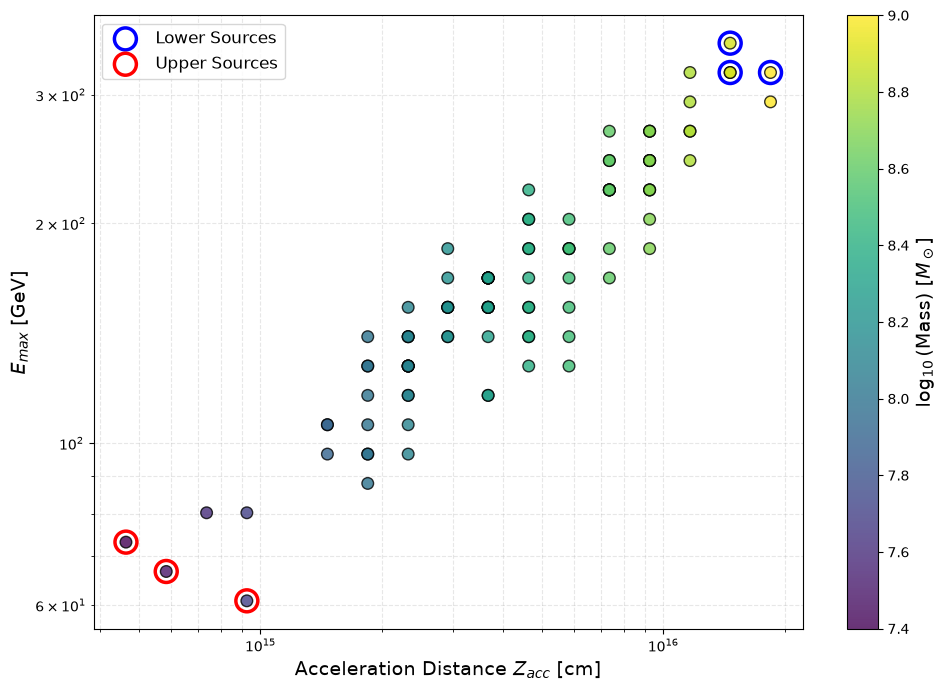

In [8]:
import csv
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

ELECTRON_DIR = "data_iron"
source_file = "source.txt"
params_file = "all_calculated_parameters.csv"

# Exact names of the sources identified previously
lower_sources = ['SDSS J135226.71+140528.5', 'SDSS J075354.98+130916.5', 'SDSS J114232.84+262919.9']
upper_sources = ['SDSS J140528.32+304602.0', 'SDSS J150636.57+092618.3', 'SDSS J090734.91+325722.9']

E_common = np.logspace(-3, 5, 200)

population_data = {
    'names': [],
    'E_max': [],
    'Z_acc': [],
    'mass': []
}

print("Loading the calculated parameters file...")
# 1. Read all_calculated_parameters.csv using Pandas
df_params = pd.read_csv(params_file)

# Create a dictionary where the key is the 'Source_Name' for ultra-fast indexing
params_dict = df_params.set_index('Source_Name').to_dict('index')

print("Reading rate files and extracting E_max...")

with open(source_file, mode='r') as csvfile:
    reader = csv.DictReader(csvfile)
    
    for row in reader:
        name = row['name']
        filename = f"{ELECTRON_DIR}/{name}_electrons.csv"
        
        if not os.path.exists(filename):
            continue
            
        # 2. Extract Mass (M) and Acceleration Distance (Z_acc_cm)
        if name in params_dict:
            Z_acc_val = float(params_dict[name]['Z_acc_cm']) 
            mass_val = float(params_dict[name]['M'])
        else:
            print(f"Warning: Source {name} not found in {params_file}")
            continue
            
        E_tmp, acc_tmp, cool_tmp = [], [], []
        
        # 3. Read the electrons CSV and calculate cooling / acceleration rates
        with open(filename, 'r') as f:
            csv_reader = csv.DictReader(f)
            for d in csv_reader:
                E_tmp.append(float(d['E_GeV']))
                acc_tmp.append(float(d['rate_acc']))
                total_cool = float(d['rate_sync']) + float(d['rate_bremss']) + float(d['rate_ic_0']) + float(d['rate_ic_1'])
                cool_tmp.append(total_cool)
                
        f_acc = interp1d(E_tmp, acc_tmp, fill_value="extrapolate")
        f_cool = interp1d(E_tmp, cool_tmp, fill_value="extrapolate")
        
        acc_interp = f_acc(E_common)
        cool_interp = f_cool(E_common)
        
        # Find E_max (intersection point where cooling > acceleration)
        idx_max = np.where(cool_interp > acc_interp)[0]
        if len(idx_max) > 0:
            e_m = E_common[idx_max[0]]
        else:
            e_m = E_common[-1]
            
        # Save for plotting
        population_data['names'].append(name)
        population_data['E_max'].append(e_m)
        population_data['Z_acc'].append(Z_acc_val)
        population_data['mass'].append(mass_val)

# Convert populated lists to Numpy arrays
names_array = np.array(population_data['names'])
E_max_array = np.array(population_data['E_max'])
Z_acc_array = np.array(population_data['Z_acc'])
mass_array = np.array(population_data['mass'])

# ==========================================
# PLOT GENERATION: Z_acc vs E_max with mass colormap
# ==========================================
fig, ax = plt.subplots(figsize=(10, 7))

# General population plot encoded with Log10 of Mass
sc = ax.scatter(Z_acc_array, E_max_array, c=np.log10(mass_array), cmap='viridis', 
                s=70, alpha=0.8, edgecolors='k', zorder=2)

lower_label_added = False
upper_label_added = False

# Highlight overlay (Lower and Upper)
for i, name in enumerate(names_array):
    if name in lower_sources:
        ax.scatter(Z_acc_array[i], E_max_array[i], facecolors='none', edgecolors='blue', 
                   s=250, linewidth=2.5, zorder=3, 
                   label='Lower Sources' if not lower_label_added else "")
        lower_label_added = True
    elif name in upper_sources:
        ax.scatter(Z_acc_array[i], E_max_array[i], facecolors='none', edgecolors='red', 
                   s=250, linewidth=2.5, zorder=3, 
                   label='Upper Sources' if not upper_label_added else "")
        upper_label_added = True

ax.set_xscale('log')
ax.set_yscale('log')

# Updating labels for the new Z_acc metric
ax.set_xlabel(r'Acceleration Distance $Z_{acc}$ [cm]', fontsize=14)
ax.set_ylabel(r'$E_{max}$ [GeV]', fontsize=14)
#ax.set_title(r'$E_{max}$ vs Acceleration Distance ($Z_{acc}$) with Mass Variation', fontsize=14)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r'$\log_{10}$(Mass) [$M_\odot$]', fontsize=14)

ax.legend(loc='best', fontsize=12)
ax.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()